In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA_DIR = Path('../../example/filter_comparaison')

NO_FILTER_FILE = (
    DATA_DIR /f"filtered_pairs_500_800_HiGHS_CMD_threads_4_comparaison_no_filter.csv"
)

WITH_FILTER_FILE = (
     DATA_DIR /f"filtered_pairs_500_800_HiGHS_CMD_threads_4_comparaison_with_filter.csv"
)

df_no_filter = pd.read_csv(NO_FILTER_FILE)
df_with_filter = pd.read_csv(WITH_FILTER_FILE)

print("Without new filter:", df_no_filter.shape)
print("With new filter:", df_with_filter.shape)

Without new filter: (47, 25)
With new filter: (47, 25)


In [3]:
NEW_FILTER_COL = "d_incident"

EXACT_COL = "exact_distance"
NEW_FILTER_COL = "d_incident"
THRESHOLD_COL = "actual_threshold"

In [4]:
pairs_no = set(df_no_filter["pair_id"])
pairs_with = set(df_with_filter["pair_id"])

print("Pairs without filter:", len(pairs_no))
print("Pairs with filter:", len(pairs_with))

print(
    "Same pair IDs:",
    pairs_no == pairs_with
)

print(
    "Only in no-filter:",
    pairs_no - pairs_with
)

print(
    "Only in with-filter:",
    pairs_with - pairs_no
)

Pairs without filter: 47
Pairs with filter: 47
Same pair IDs: True
Only in no-filter: set()
Only in with-filter: set()


In [5]:
comparison = df_no_filter.merge(
    df_with_filter,
    on="pair_id",
    suffixes=("_no_filter", "_with_filter")
)

print(comparison.shape)

comparison.head()

(47, 49)


,pair_id,smiles1_no_filter,smiles2_no_filter,mass1_no_filter,mass2_no_filter,mass_diff_no_filter,runtime_sec_no_filter,runtime_inside_mces_no_filter,distance_no_filter,compute_mode_no_filter,...,error_message_with_filter,result_type_with_filter,is_exact_with_filter,is_lower_bound_with_filter,d1_with_filter,d_bond_with_filter,d_incident_with_filter,d2_with_filter,d_rascal_with_filter,exact_distance_with_filter
0,1879,[H][C@](COC(=O)CCCCCCCCC)(COC(=O)CCCCCCCCCCCCC...,[H][C@](COC(=O)CCCCCCCCC)(COC(=O)CCCCCCCCCCCCC...,723.177,723.177,2.270000e-13,36.116065,31.994911,4.0,1.0,...,NaN,exact,1,0,0.0,0.0,0.0,0.0,0,4.0
1,3585,[H][C@@](COC(=O)CCCCCCCCCCCCCCC)(COC(=O)CCCCCC...,[H][C@@](COC(=O)CCCCCCCCCCCCC(C)CC)(COC(=O)CCC...,793.312,793.312,1.140000e-13,10.330787,7.018330,4.0,1.0,...,NaN,exact,1,0,2.0,0.0,4.0,2.0,0,4.0
2,3623,CC[C@H](O)\C=C\C=C/C\C=C/C\C=C/C\C=C/CCCC(=O)O...,CC1OC(CC(C1OS(C)(=O)=O)N1CC1)OC1CC(O)(CC2=C(O)...,602.897,601.630,1.267000e+00,2.654265,0.003023,25.0,2.0,...,NaN,lower_bound,0,1,25.0,NaN,NaN,NaN,0,44.0
3,7864,CCCCC[C@H](O)\C=C\[C@H]1[C@H](O)CC(=O)[C@@H]1C...,[H][C@@](COC(=O)CCCCCCCCCCCCCCCCCC)(COC(=O)CCC...,764.931,765.258,3.270000e-01,3.227454,0.002086,20.0,2.0,...,NaN,lower_bound,0,1,20.0,NaN,NaN,NaN,0,27.0
4,8016,CCCCC\C=C/C\C=C/C\C=C/CCCCC(=O)O[C@H](COC(=O)C...,[H][C@@](COC(=O)CCCCCCCCCCCCCCCCC(C)C)(COC(=O)...,792.004,793.312,1.308000e+00,2.476460,0.003064,17.0,2.0,...,NaN,lower_bound,0,1,17.0,NaN,NaN,NaN,0,27.0


In [6]:
solver_calls_no = df_no_filter["solverCalled"].sum()
solver_calls_with = df_with_filter["solverCalled"].sum()

print("Solver calls without new filter:", solver_calls_no)
print("Solver calls with new filter:", solver_calls_with)

print(
    "Difference:",
    solver_calls_no - solver_calls_with
)

Solver calls without new filter: 20
Solver calls with new filter: 21
Difference: -1


In [7]:
solver_transition = pd.crosstab(
    comparison["solverCalled_no_filter"],
    comparison["solverCalled_with_filter"],
    rownames=["Without filter"],
    colnames=["With filter"]
)

solver_transition

With filter,0,1
Without filter,,
0,22,5
1,4,16


In [8]:
new_filter_rejections = df_with_filter[
    df_with_filter[NEW_FILTER_COL].notna()
    &
    (
        df_with_filter[NEW_FILTER_COL]
        >
        df_with_filter[THRESHOLD_COL]
    )
].copy()

print(
    "Pairs rejected by the new two-hop filter:",
    len(new_filter_rejections)
)

new_filter_rejections[
    [
        "pair_id",
        "d1",
        "d_bond",
        NEW_FILTER_COL,
        "d2",
        "exact_distance",
        "actual_threshold"
    ]
]

Pairs rejected by the new two-hop filter: 4


,pair_id,d1,d_bond,d_incident,d2,exact_distance,actual_threshold
6,28208,7.0,0.0,11.00,7.0,14.0,10
15,42470,9.0,0.0,11.00,9.0,11.0,10
35,93324,7.0,0.0,10.75,8.0,12.0,10
42,101536,9.0,0.0,14.00,10.0,14.0,10


In [9]:
previous_filters_passed = (
    (df_with_filter["d1"] <= df_with_filter[THRESHOLD_COL])
    &
    (
        df_with_filter["d_bond"].isna()
        |
        (
            df_with_filter["d_bond"]
            <=
            df_with_filter[THRESHOLD_COL]
        )
    )
)

new_filter_additional = df_with_filter[
    previous_filters_passed
    &
    df_with_filter[NEW_FILTER_COL].notna()
    &
    (
        df_with_filter[NEW_FILTER_COL]
        >
        df_with_filter[THRESHOLD_COL]
    )
].copy()

print(
    "Additional pairs rejected specifically by the new filter:",
    len(new_filter_additional)
)

new_filter_additional[
    [
        "pair_id",
        "d1",
        "d_bond",
        NEW_FILTER_COL,
        "d2",
        "exact_distance"
    ]
]

Additional pairs rejected specifically by the new filter: 4


,pair_id,d1,d_bond,d_incident,d2,exact_distance
6,28208,7.0,0.0,11.00,7.0,14.0
15,42470,9.0,0.0,11.00,9.0,11.0
35,93324,7.0,0.0,10.75,8.0,12.0
42,101536,9.0,0.0,14.00,10.0,14.0


In [10]:
new_solver_calls = comparison[
    (comparison["solverCalled_no_filter"] == 0) &
    (comparison["solverCalled_with_filter"] == 1)
]

new_solver_calls[
    [
        "pair_id",
        "distance_no_filter",
        "distance_with_filter",
        "d1_no_filter",
        "d1_with_filter",
        "d2_no_filter",
        "d2_with_filter",
        "exact_distance_no_filter",
        "exact_distance_with_filter"
    ]
]

,pair_id,distance_no_filter,distance_with_filter,d1_no_filter,d1_with_filter,d2_no_filter,d2_with_filter,exact_distance_no_filter,exact_distance_with_filter
11,33751,NaN,6.0,NaN,0.0,NaN,0.0,6.0,6.0
17,44757,NaN,6.0,NaN,1.0,NaN,1.0,8.0,8.0
20,47035,NaN,6.0,NaN,0.0,NaN,0.0,30.0,30.0
24,61065,NaN,6.0,NaN,0.0,NaN,0.0,6.0,6.0
30,85717,NaN,6.0,NaN,2.0,NaN,2.0,6.0,6.0


In [11]:
def classify_pair(row):

    if pd.isna(row["distance"]):
        return "timeout_or_failed"

    if row["solverCalled"] == 1:
        return "solver"

    return "filtered"


df_no_filter["status"] = df_no_filter.apply(
    classify_pair,
    axis=1
)

df_no_filter["status"].value_counts()

status
filtered             22
solver               20
timeout_or_failed     5
Name: count, dtype: int64

In [12]:
df_with_filter["status"] = df_with_filter.apply(
    classify_pair,
    axis=1
)

df_with_filter["status"].value_counts()

status
filtered    26
solver      21
Name: count, dtype: int64

In [19]:
status_table = pd.crosstab(
    df_no_filter["status_no_filter"],
    df_with_filter["status_with_filter"]
)

status_table

KeyError: 'status_no_filter'

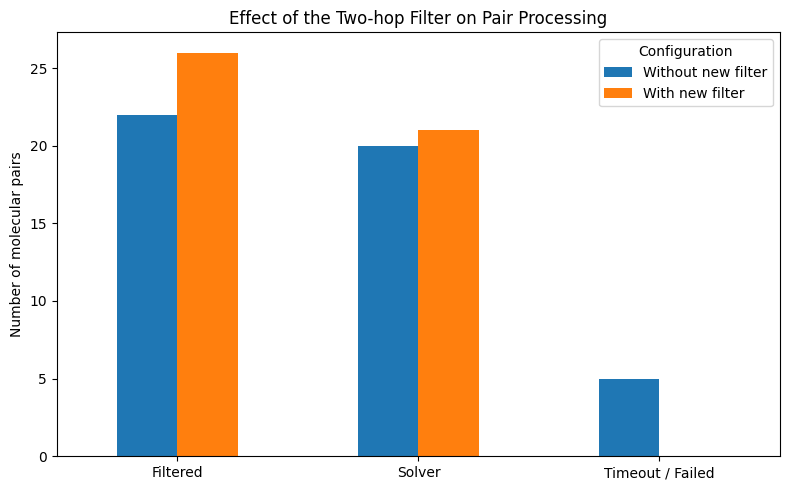

In [20]:
summary_status = pd.DataFrame({
    "Without new filter": [
        (df_no_filter["status"] == "filtered").sum(),
        (df_no_filter["status"] == "solver").sum(),
        (df_no_filter["status"] == "timeout_or_failed").sum()
    ],
    "With new filter": [
        (df_with_filter["status"] == "filtered").sum(),
        (df_with_filter["status"] == "solver").sum(),
        (df_with_filter["status"] == "timeout_or_failed").sum()
    ]
},
index=[
    "Filtered",
    "Solver",
    "Timeout / Failed"
])

summary_status.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("Number of molecular pairs")

plt.title(
    "Effect of the Two-hop Filter on Pair Processing"
)

plt.xticks(rotation=0)

plt.legend(
    title="Configuration"
)

plt.tight_layout()
plt.show()

In [18]:
still_filtered = len(
    status_comparison[
        (status_comparison["status_no_filter"] == "filtered")
        &
        (status_comparison["status_with_filter"] == "filtered")
    ]
)

avoided_ilp = len(
    status_comparison[
        (status_comparison["status_no_filter"] == "solver")
        &
        (status_comparison["status_with_filter"] == "filtered")
    ]
)

still_solver = len(
    status_comparison[
        (status_comparison["status_no_filter"] == "solver")
        &
        (status_comparison["status_with_filter"] == "solver")
    ]
)

recovered_timeouts = len(
    status_comparison[
        (status_comparison["status_no_filter"] == "timeout_or_failed")
        &
        (status_comparison["status_with_filter"] == "solver")
    ]
)

contribution = pd.Series({
    "Still filtered": still_filtered,
    "ILP calls avoided": avoided_ilp,
    "Still required ILP": still_solver,
    "Previous timeouts recovered": recovered_timeouts
})

contribution.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("Number of molecular pairs")

plt.title(
    "Contribution of the Two-hop Filter"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

NameError: name 'status_comparison' is not defined

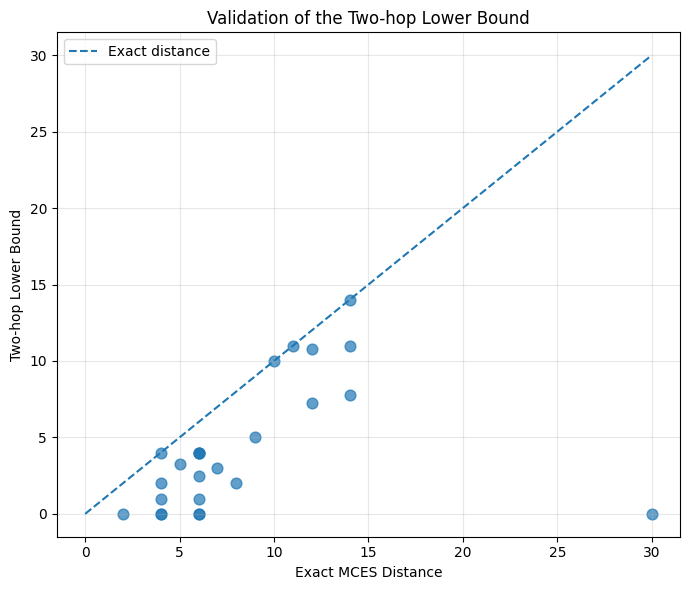

In [15]:
validation = df_with_filter[
    df_with_filter[NEW_FILTER_COL].notna()
    &
    df_with_filter[EXACT_COL].notna()
].copy()

plt.figure(figsize=(7, 6))

plt.scatter(
    validation[EXACT_COL],
    validation[NEW_FILTER_COL],
    s=60,
    alpha=0.7
)

min_val = min(
    validation[EXACT_COL].min(),
    validation[NEW_FILTER_COL].min()
)

max_val = max(
    validation[EXACT_COL].max(),
    validation[NEW_FILTER_COL].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="Exact distance"
)

plt.xlabel("Exact MCES Distance")

plt.ylabel(
    "Two-hop Lower Bound"
)

plt.title(
    "Validation of the Two-hop Lower Bound"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
EPS = 1e-9

validation = df_with_filter[
    df_with_filter[NEW_FILTER_COL].notna()
    &
    df_with_filter[EXACT_COL].notna()
].copy()

violations = validation[
    validation[NEW_FILTER_COL]
    >
    validation[EXACT_COL] + EPS
]

print("Pairs validated:", len(validation))
print("Violations:", len(violations))

violations[
    [
        "pair_id",
        NEW_FILTER_COL,
        EXACT_COL
    ]
]

Pairs validated: 25
Violations: 0


,pair_id,d_incident,exact_distance


In [17]:
# -----------------------------------------
# FILTER CONTRIBUTION ANALYSIS
# -----------------------------------------

NEW_FILTER_COL = "d_incident"
THRESHOLD_COL = "actual_threshold"

df = df_with_filter.copy()

# Create a column that stores which filter
# first rejects each molecular pair
df["pruned_by"] = "Not filtered / ILP"

# -------------------------------------------------
# 1. First filter: d1
# -------------------------------------------------
mask_d1 = (
    df["d1"].notna()
    &
    (df["d1"] > df[THRESHOLD_COL])
)

df.loc[mask_d1, "pruned_by"] = "d1"


# -------------------------------------------------
# 2. Second filter: d2
# Only consider pairs not already rejected by d1
# -------------------------------------------------
mask_d2 = (
    (df["pruned_by"] == "Not filtered / ILP")
    &
    df["d2"].notna()
    &
    (df["d2"] > df[THRESHOLD_COL])
)

df.loc[mask_d2, "pruned_by"] = "d2"


# -------------------------------------------------
# 3. New two-hop filter
# Only consider pairs surviving d1 and d2
# -------------------------------------------------
mask_two_hop = (
    (df["pruned_by"] == "Not filtered / ILP")
    &
    df[NEW_FILTER_COL].notna()
    &
    (df[NEW_FILTER_COL] > df[THRESHOLD_COL])
)

df.loc[mask_two_hop, "pruned_by"] = "Two-hop"


# -------------------------------------------------
# Count contribution
# -------------------------------------------------

order = [
    "d1",
    "d2",
    "Two-hop",
    "Not filtered / ILP"
]

contribution = (
    df["pruned_by"]
    .value_counts()
    .reindex(order, fill_value=0)
)

print(contribution)

pruned_by
d1                    18
d2                     4
Two-hop                4
Not filtered / ILP    21
Name: count, dtype: int64
